<a href="https://colab.research.google.com/github/apcyssr/2026_Spring_KBU/blob/main/20260403_APICHAYA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import requests
from bs4 import BeautifulSoup

url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

In [17]:
# 1. 모든 h3 태그 안의 a 태그를 찾습니다.
titles = [a['title'] for a in soup.select('h3 a')]

# 결과 출력
for title in titles:
    print(title)

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


In [8]:
import pandas as pd

df_titles = pd.DataFrame(titles, columns=['Book Titles'])
df_titles

,Book Titles
0,A Light in the Attic
1,Tipping the Velvet
2,Soumission
3,Sharp Objects
4,Sapiens: A Brief History of Humankind
5,The Requiem Red
6,The Dirty Little Secrets of Getting Your Dream...
7,The Coming Woman: A Novel Based on the Life of...
8,The Boys in the Boat: Nine Americans and Their...
9,The Black Maria


In [12]:
df = pd.DataFrame(all_books_data)

In [13]:
top_10_expensive = df.sort_values(by='Price', ascending=False).head(10)

In [14]:
top_10_expensive

,Category,Title,Price
46,Classics,Candide,58.63
51,Philosophy,The Death of Humanity: and the Case for Life,58.11
93,Childrens,The White Cat and the Monk: A Retelling of the...,58.08
70,Womens Fiction,I Had a Nice Time And Other Lies...: How to fi...,57.36
47,Classics,Animal Farm,57.22
7,Travel,A Year in Provence (Provence #1),56.88
12,Mystery,The Past Never Ends,56.50
92,Childrens,The Secret of Dreadwillow Carse,56.13
66,Romance,Suddenly in Love (Lake Haven #1),55.99
22,Historical Fiction,A Flight of Arrows (The Pathfinders #2),55.53


Shapiro-Wilk Statistic: 0.9158
p-value: 0.0000
결론: p-value <= 0.05 이므로 정규분포를 따른다고 볼 수 없습니다. (H0 기각)


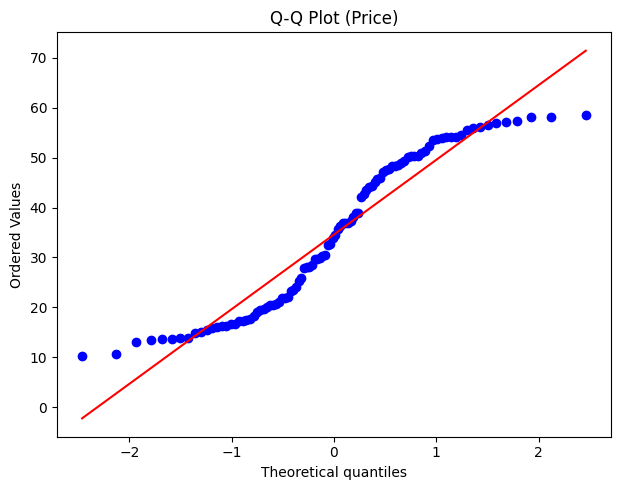

In [19]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Q-Q Plot Test
plt.figure(figsize=(12, 5))

# สรา้ง Q-Q Plot
plt.subplot(1, 2, 1)
stats.probplot(df['Price'], dist="norm", plot=plt)
plt.title('Q-Q Plot (Price)')

# 2. Shapiro-Wilk Test
# shapiro() จะคืนค่ามา 2 อย่างคือ statistic และ p-value
statistic, p_value = stats.shapiro(df['Price'])

print(f"Shapiro-Wilk Statistic: {statistic:.4f}")
print(f"p-value: {p_value:.4f}")

# แปลผลทางสถิติ (Statistical Significance)
alpha = 0.05
if p_value > alpha:
    print("결론: p-value > 0.05 이므로 정규분포를 따른다고 볼 수 있습니다. (H0 채택)")
else:
    print("결론: p-value <= 0.05 이므로 정규분포를 따른다고 볼 수 없습니다. (H0 기각)")

plt.tight_layout()
plt.show()